In [1]:
import glob
import numpy
import pandas
import seaborn
import matplotlib.pyplot as plt
import multiprocessing as mp
import os
from build import build_model
import coralme
from tqdm import tqdm
plt.rcParams["svg.fonttype"] = "none"


In [2]:
from IPython.display import display, HTML, Math, Markdown
display(HTML("<style>.container { width:95% !important; }</style>"))

%load_ext autoreload
%autoreload 2

### Load annotation

In [3]:
def load_annotation(path,column = "subsystem"):
    try:
        df = pandas.read_csv(path,index_col=0)[[column]]
    except:
        df = pandas.DataFrame(columns=[column])
    df.columns = [org]
    return df

In [4]:
organisms = set(pandas.read_csv("biomass_constrained.txt",index_col=0,header=None).index.to_list())
subsystems = {}
for org in tqdm(organisms):
    tmp = load_annotation("./datasets/m_subsystems/{}.csv".format(org),column="0")
    # tmp[org] = tmp[org].apply(lambda x:"{}:{}".format(org,x))
    subsystems.update(tmp[org].to_dict())
subsystems = pandas.Series(subsystems,name="subsystems")

  0%|          | 0/495 [00:00<?, ?it/s]

100%|██████████| 495/495 [00:00<00:00, 867.89it/s]


In [5]:
organisms = set(pandas.read_csv("biomass_constrained.txt",index_col=0,header=None).index.to_list())
gene_subsystems = {}
for org in tqdm(organisms):
    tmp = load_annotation("./datasets/subsystems/{}.csv".format(org))
    # tmp[org] = tmp[org].apply(lambda x:"{}:{}".format(org,x))
    tmp[org] = tmp[org].apply(lambda x:x.split(":")[-1])
    gene_subsystems.update(tmp[org].to_dict())
gene_subsystems = pandas.Series(gene_subsystems,name="subsystems")

  0%|          | 0/495 [00:00<?, ?it/s]

100%|██████████| 495/495 [00:00<00:00, 801.33it/s]


### Load fluxes

In [6]:
def load_data(path):
    try:
        df = pandas.read_csv(path,index_col=0)[["fluxes"]]
    except:
        df = pandas.DataFrame(columns=["fluxes"])
    df.columns = [org]
    return df

In [55]:
conditions = ["IBD","nonIBD"]
Fluxes = {}
for c in conditions:
    # c = "IBD"
    organisms = set(pandas.read_csv("biomass_constrained.txt",index_col=0,header=None).index.to_list())
    fluxes = pandas.Series()
    for org in tqdm(organisms):
        tmp = load_data("./cases/m/fluxes/{}/{}.csv".format(c,org)).abs()
        if fluxes.empty:
            fluxes = pandas.Series({i:0 for i in tmp.index})
        fluxes = fluxes + tmp[org]
    # fluxes = pandas.Series(fluxes,name="fluxes")
    Fluxes[c] = pandas.Series(fluxes,name="fluxes")
Fluxes = pandas.DataFrame(Fluxes)
Fluxes.columns = [i+"_fluxes" for i in Fluxes.columns]

  0%|          | 0/495 [00:00<?, ?it/s]

100%|██████████| 495/495 [00:00<00:00, 584.63it/s]


In [59]:
cutoff = 1e-6
Fluxes = Fluxes.where(Fluxes>cutoff,other=cutoff)

In [60]:
FluxesAnnotated = pandas.concat([Fluxes,subsystems],axis=1).dropna()
FluxesAnnotated.head()

,IBD_fluxes,nonIBD_fluxes,subsystems
12DGR180ti,0.000001,0.000001,"Transport, extracellular"
12PPDSDH,0.000001,0.000001,Propanoate metabolism
12PPDt,0.000001,0.000001,"Transport, extracellular"
12aHSDHe,0.000001,0.000001,Bile acid metabolism
13PPDHr,0.000001,0.000001,Glycerophospholipid metabolism


### Load metaT and convert to CPM

In [61]:
metaT = pandas.read_csv("./ibdmdb/metaT_aligned/samfiles/Custom_index_counts.tsv", sep ='\t',index_col=0)
metaT.columns = [i.split("_")[0] for i in metaT.columns]

In [62]:
ProcessedMetadata = pandas.read_csv("ibdmdb/processed_metadata.csv",index_col=0)

In [63]:
NormalizedRNA = metaT.div(metaT.sum())*1e6

In [64]:
MeanTCounts = pandas.DataFrame()
for d in ProcessedMetadata["diagnosis"].unique():
    tmp = NormalizedRNA[ProcessedMetadata[ProcessedMetadata["diagnosis"]==d]["metaT_run"].values]
    MeanTCounts[d] = tmp.mean(axis=1).sort_values(ascending=False)
tmp = NormalizedRNA[ProcessedMetadata[ProcessedMetadata["diagnosis"]==d]["metaT_run"].values]
MeanTCounts["IBD"] = tmp.mean(axis=1).sort_values(ascending=False)
MeanTCounts.head()

,nonIBD,UC,CD,IBD
#FeatureID,,,,
HMPREF9436_RS14285,78977.476940,33842.360427,45532.400109,45532.400109
HMPREF9436_RS14685,18978.991462,7302.183167,11759.055528,11759.055528
FAEPRAM212_RS14865,17331.121892,24719.790664,32613.689568,32613.689568
BSFG_RS23450,14414.558879,11660.353071,11011.024919,11011.024919
HMPREF9011_RS23455,14369.061379,11648.350875,10953.488388,10953.488388


In [65]:
MeanTCountsAnnotated = pandas.concat([MeanTCounts[["nonIBD","IBD"]]+1,gene_subsystems],axis=1).dropna()
MeanTCountsAnnotated.head()

,nonIBD,IBD,subsystems
A3CY_RS23185,8544.909268,5310.634949,Translation
A3CY_RS0112425,3035.053220,780.872609,Translation
748224.3.peg.559,2418.869054,1550.264361,Pyruvate metabolism
748224.3.peg.806,1739.561076,368.609326,Translation
748224.3.peg.1671,1184.487408,180.264027,Translation


### Compare

In [66]:
ComparedGroupedBySubsystem = pandas.concat([FluxesAnnotated.groupby("subsystems").sum(),
                          MeanTCountsAnnotated.groupby("subsystems").sum()],axis=1).dropna()
ComparedGroupedBySubsystem.head()

,IBD_fluxes,nonIBD_fluxes,nonIBD,IBD
subsystems,,,,
Alanine and aspartate metabolism,0.000020,0.000020,4216.840692,4511.608102
Aminobenzoate degradation,0.000006,0.000006,468.464926,466.524077
Aminophosphonate metabolism,0.000001,0.000001,28.377842,27.456544
Aminosugar metabolism,4.705384,0.093337,5857.508778,6184.734564
Arginine and proline metabolism,0.000065,0.000065,3426.506927,3598.921809


### Correlation

In [67]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import summary_table
from scipy import stats
from scipy.stats import pearsonr

In [72]:
def plot_regression(predicted,experimental,ax):
    def annotate_corr(ax,r_value, p_value,n_samples):
        ax.text(
            0.05, 0.9,
            f"PCC = {r_value:.2f}\np = {p_value:.2g}\nn = {n_samples:d}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5)
        )
    sample = experimental
    # experimental = sample
    # predicted = sample + "_fluxes"
    color = "#2b83ba"
    tmp = ComparedGroupedBySubsystem[[experimental,predicted]].copy()
    tmp = numpy.log10(tmp).replace([numpy.inf, -numpy.inf], numpy.nan, inplace=False).dropna()
    tmp = tmp.sort_values(predicted,ascending=False)
    # colors = ["brown","blue","green"]
    X = tmp[predicted].values
    y = tmp[experimental].values

    X2 = sm.add_constant(X)
    est = sm.OLS(y, X2)
    est2 = est.fit()

    # Scatter plot
    tmp.plot.scatter(predicted,experimental,ax=ax,color=color,edgecolor="white",s=50)
    ax.plot(X,est2.predict(),color="black")

    ax.set_xlabel(f"Predicted pathway translation flux\nin {predicted}, log10")
    ax.set_ylabel(f"Predicted pathway translation flux\nin {experimental}, log10")

    res = pearsonr(numpy.squeeze(y),numpy.squeeze(est2.predict().reshape(-1,1)))
    # print(res)
    r_value = res.statistic
    p_value = res.pvalue
    n_samples = len(y)
    # Confidence interval
    st, data, ss2 = summary_table(est2, alpha=0.05)
    fittedvalues = data[:, 2]
    predict_mean_se  = data[:, 3]
    predict_mean_ci_low, predict_mean_ci_upp = data[:, 4:6].T
    predict_ci_low, predict_ci_upp = data[:, 6:8].T
    ax.plot(X, predict_ci_low, color="gray")
    ax.plot(X, predict_ci_upp, color="gray")

    annotate_corr(ax,r_value, p_value,n_samples)

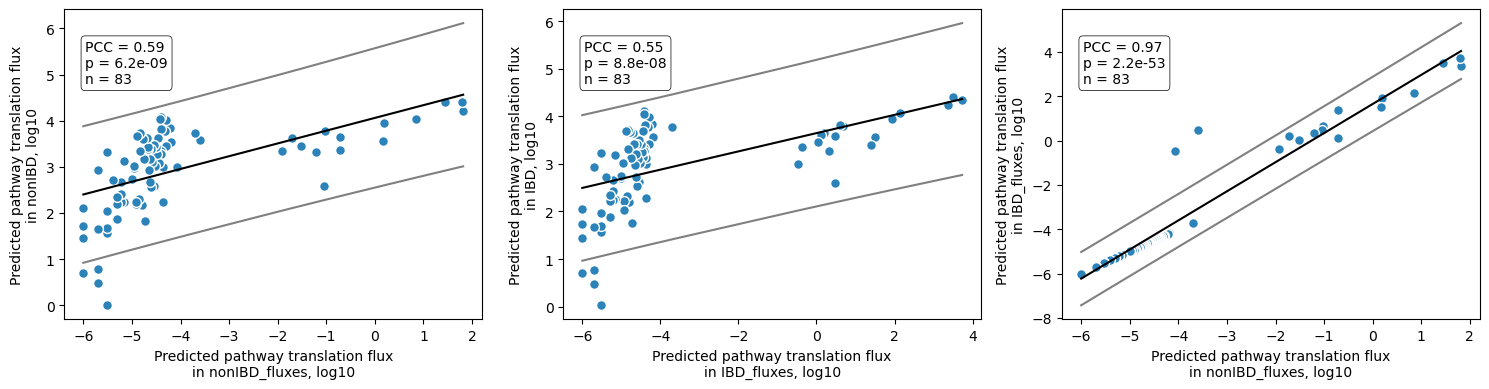

In [73]:
fig,ax = plt.subplots(1,3,figsize=(15,4))
plot_regression("nonIBD_fluxes","nonIBD",ax=ax[0])
plot_regression("IBD_fluxes","IBD",ax=ax[1])
plot_regression("nonIBD_fluxes","IBD_fluxes",ax=ax[2])
fig.tight_layout()
fig.savefig("figures/3.M_fluxes_vs_transcriptome.svg", dpi=300, bbox_inches='tight',format="svg")

In [ ]:
fold = numpy.log10(ComparedGroupedBySubsystem["IBD_fluxes"]/ComparedGroupedBySubsystem["nonIBD_fluxes"])
print(fold.mean(),fold.std())

2.044877128368512 1.766425008868098


### Pairplot

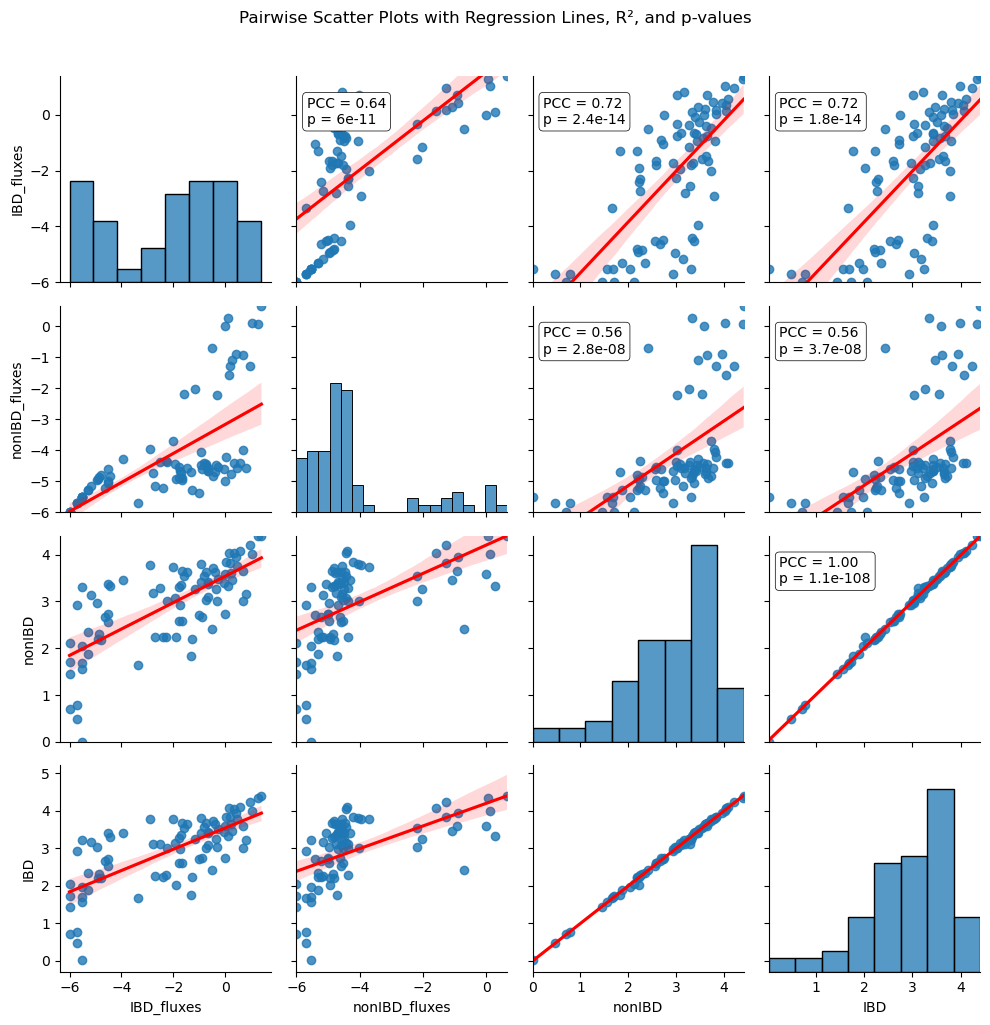

In [ ]:
import seaborn as sns
from scipy.stats import linregress
# Custom function to add regression lines and annotations
def pairplot_with_stats(data):
    def annotate_corr(x, y, **kwargs):
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        ax = plt.gca()
        ax.text(
            0.05, 0.9,
            f"PCC = {r_value:.2f}\np = {p_value:.2g}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.5)
        )

    # Plot with regression line and histogram
    g = sns.pairplot(data, kind='reg', diag_kind='hist', plot_kws={'line_kws': {'color': 'red'}})

    # Annotate with R² and p-value
    for i, j in zip(*numpy.triu_indices_from(g.axes, 1)):
        x = data.iloc[:, j]
        y = data.iloc[:, i]
        plt.sca(g.axes[i, j])
        plt.xlim(x.min(), x.max())
        plt.ylim(y.min(), y.max())
        annotate_corr(x, y)

    plt.suptitle("Pairwise Scatter Plots with Regression Lines, R², and p-values", y=1.02)
    plt.tight_layout()
    # plt.show()

# Run the function on your dataframe
df = numpy.log10(ComparedGroupedBySubsystem).replace([numpy.inf, -numpy.inf], numpy.nan, inplace=False).dropna()
pairplot_with_stats(df)